# DataCo Supply Chain — Dataset Overview

This notebook gives a first-pass overview of the two files in this archive:

- **`DataCoSupplyChainDataset.csv`** — order-line level supply chain / sales transactions (~180K rows).
- **`tokenized_access_logs.csv`** — web clickstream logs for the same storefront.
- **`DescriptionDataCoSupplyChain.csv`** — the data dictionary for the transactions file.

Goal: shape, schema, missing data, date coverage, and the main categorical/numeric distributions — enough to plan deeper EDA notebooks from here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

# Palette (fixed categorical order — never cycled/reassigned by filters)
CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY,
    'text.color': INK,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False):
    ax.grid(axis='x' if x_grid else 'y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

DATA_DIR = '.'  # run this notebook from inside the archive folder

## 1. Data dictionary

The supplier-provided description of every field in the transactions file.

In [2]:
desc = pd.read_csv(f'{DATA_DIR}/DescriptionDataCoSupplyChain.csv', encoding='latin1')
desc.columns = ['field', 'description']
desc['description'] = desc['description'].str.lstrip(': ').str.strip()
pd.set_option('display.max_colwidth', 160)
desc

,field,description
0,Type,Type of transaction made
1,Days for shipping (real),Actual shipping days of the purchased product
2,Days for shipment (scheduled),Days of scheduled delivery of the purchased product
3,Benefit per order,Earnings per order placed
4,Sales per customer,Total sales per customer made per customer
5,Delivery Status,"Delivery status of orders: Advance shipping , Late delivery , Shipping canceled , Shipping on time"
6,Late_delivery_risk,"Categorical variable that indicates if sending is late (1), it is not late (0)."
7,Category Id,Product category code
8,Category Name,Description of the product category
9,Customer City,City where the customer made the purchase


## 2. Transactions dataset — shape & schema

In [3]:
df = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
print(f'{df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:,.1f} MB')

180,519 rows x 53 columns
Memory usage: 313.4 MB


In [4]:
df.dtypes.rename('dtype').to_frame()

,dtype
Type,str
Days for shipping (real),int64
Days for shipment (scheduled),int64
Benefit per order,float64
Sales per customer,float64
Delivery Status,str
Late_delivery_risk,int64
Category Id,int64
Category Name,str
Customer City,str


In [5]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## 3. Missing values

Only a handful of columns carry nulls; the rest of the schema is fully populated.

In [6]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table

,missing_count,missing_pct
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Lname,8,0.00
Customer Zipcode,3,0.00


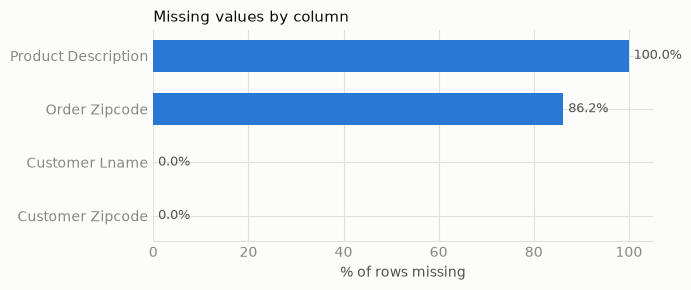

In [7]:
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(missing_table.index[::-1], missing_table['missing_pct'][::-1], color=CATEGORICAL[0], height=0.6, zorder=3)
ax.set_xlabel('% of rows missing')
ax.set_title('Missing values by column', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=True)
for bar, pct in zip(bars, missing_table['missing_pct'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', va='center', color=INK_SECONDARY, fontsize=9)
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

## 4. Date coverage

Parse the order and shipping timestamps and check the range covered.

In [8]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

print('Order dates:   ', df['order date (DateOrders)'].min(), '->', df['order date (DateOrders)'].max())
print('Shipping dates:', df['shipping date (DateOrders)'].min(), '->', df['shipping date (DateOrders)'].max())

Order dates:    2015-01-01 00:00:00 -> 2018-01-31 23:38:00
Shipping dates: 2015-01-03 00:00:00 -> 2018-02-06 22:14:00


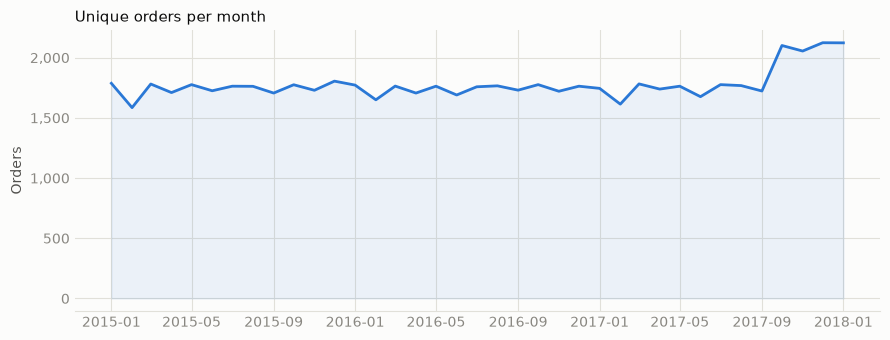

In [9]:
monthly_orders = df.set_index('order date (DateOrders)').resample('MS')['Order Id'].nunique()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(monthly_orders.index, monthly_orders.values, color=CATEGORICAL[0], linewidth=2)
ax.fill_between(monthly_orders.index, monthly_orders.values, color=CATEGORICAL[0], alpha=0.08)
ax.set_title('Unique orders per month', loc='left', color=INK, fontsize=11)
ax.set_ylabel('Orders')
style_axis(ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
plt.tight_layout()
plt.show()

## 5. Numeric fields — summary statistics

In [10]:
numeric_cols = ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order',
                'Sales per customer', 'Order Item Discount', 'Order Item Discount Rate',
                'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity',
                'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.00000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.00000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.97998,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.49000,104.379997,163.990005,247.399994,1939.989990
Order Item Discount,180519.0,20.664741,21.800901,0.00000,5.400000,14.000000,29.990000,500.000000
Order Item Discount Rate,180519.0,0.101668,0.070415,0.00000,0.040000,0.100000,0.160000,0.250000
Order Item Product Price,180519.0,141.232550,139.732492,9.99000,50.000000,59.990002,199.990005,1999.989990
Order Item Profit Ratio,180519.0,0.120647,0.466796,-2.75000,0.080000,0.270000,0.360000,0.500000
Order Item Quantity,180519.0,2.127638,1.453451,1.00000,1.000000,1.000000,3.000000,5.000000
Sales,180519.0,203.772096,132.273077,9.99000,119.980003,199.919998,299.950012,1999.989990


## 6. Categorical fields — key distributions

`Type` (payment method), `Delivery Status`, `Customer Segment`, `Shipping Mode`, `Market`, and `Order Status` — the fields most EDA questions will slice by.

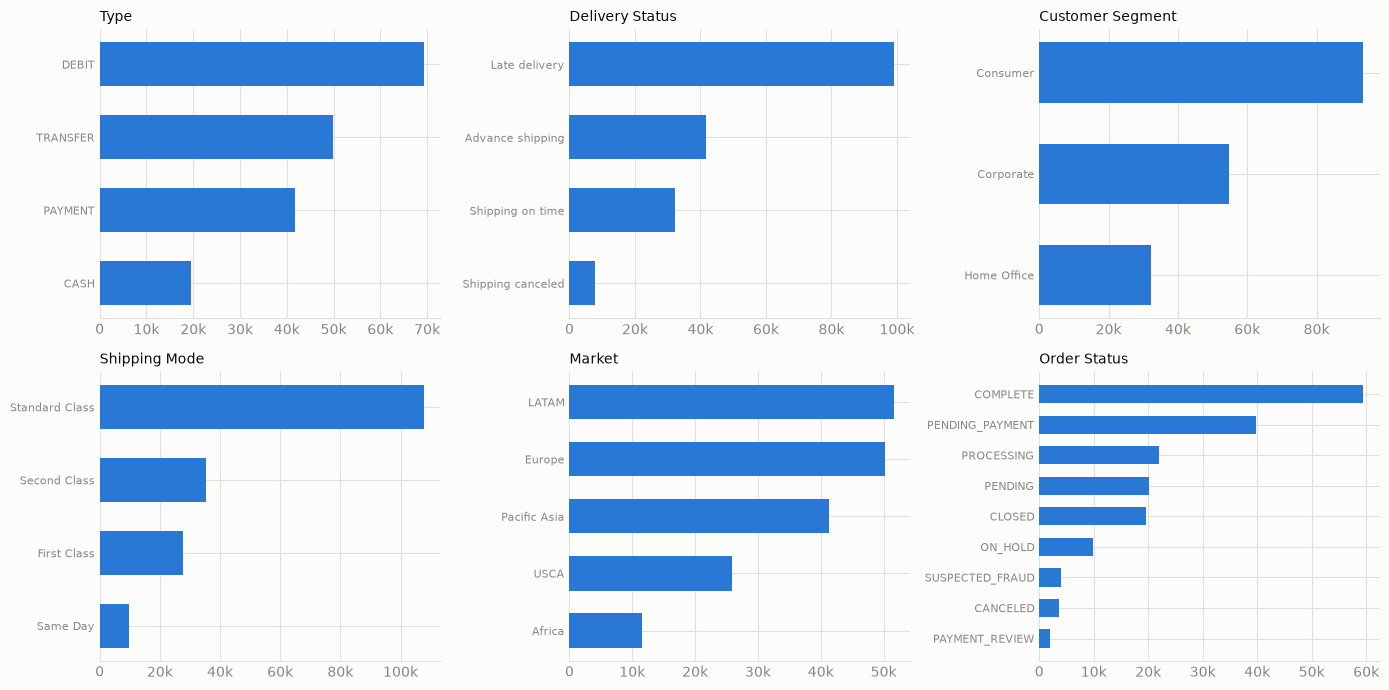

In [11]:
cat_cols = ['Type', 'Delivery Status', 'Customer Segment', 'Shipping Mode', 'Market', 'Order Status']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].value_counts().sort_values(ascending=True)
    ax.barh(counts.index, counts.values, color=CATEGORICAL[0], height=0.6, zorder=3)
    ax.set_title(col, loc='left', color=INK, fontsize=10)
    style_axis(ax, x_grid=True)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:,.0f}k' if v >= 1000 else f'{v:,.0f}'))
    for label in ax.get_yticklabels():
        label.set_fontsize(8)
plt.tight_layout()
plt.show()

## 7. Sales overview

Total sales are large enough to warrant scaling to millions rather than showing raw values or scientific notation.

In [12]:
total_sales = df['Sales'].sum()
total_profit = df['Order Profit Per Order'].sum()
print(f'Total sales:  ${total_sales/1e6:,.2f}M')
print(f'Total profit: ${total_profit/1e6:,.2f}M')
print(f'Overall margin: {total_profit/total_sales*100:,.1f}%')

Total sales:  $36.78M
Total profit: $3.97M
Overall margin: 10.8%


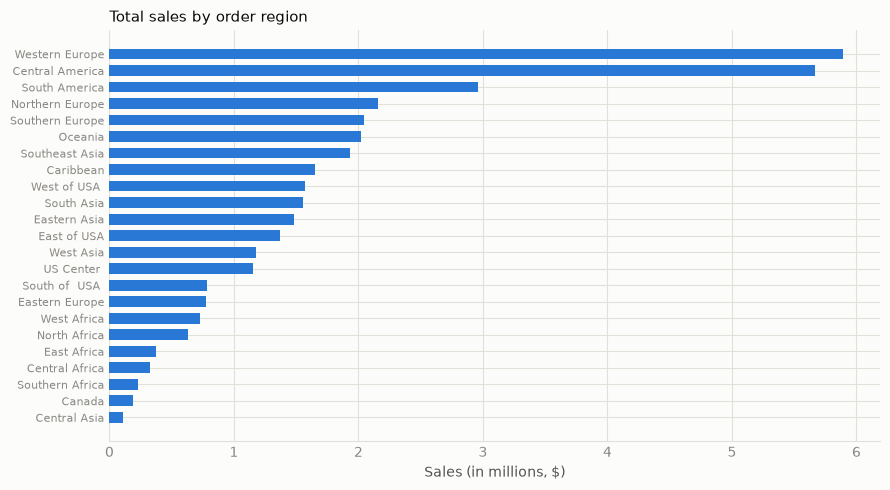

In [13]:
sales_by_region = df.groupby('Order Region')['Sales'].sum().sort_values(ascending=False) / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(sales_by_region.index[::-1], sales_by_region.values[::-1], color=CATEGORICAL[0], height=0.65, zorder=3)
ax.set_xlabel('Sales (in millions, $)')
ax.set_title('Total sales by order region', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=True)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

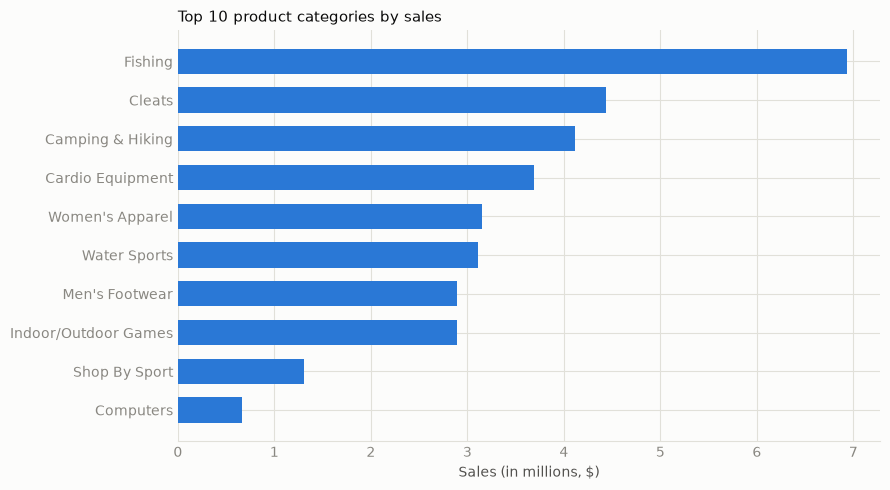

In [14]:
sales_by_cat = df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False).head(10) / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(sales_by_cat.index[::-1], sales_by_cat.values[::-1], color=CATEGORICAL[0], height=0.65, zorder=3)
ax.set_xlabel('Sales (in millions, $)')
ax.set_title('Top 10 product categories by sales', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=True)
plt.tight_layout()
plt.show()

## 8. Clickstream logs — `tokenized_access_logs.csv`

A separate web access log, joinable to the transactions file loosely via product/category/department.

In [15]:
logs = pd.read_csv(f'{DATA_DIR}/tokenized_access_logs.csv', encoding='latin1')
print(f'{logs.shape[0]:,} rows x {logs.shape[1]} columns')
logs.dtypes.rename('dtype').to_frame()

469,977 rows x 8 columns


,dtype
Product,str
Category,str
Date,str
Month,str
Hour,int64
Department,str
ip,str
url,str


In [16]:
logs.head()

,Product,Category,Date,Month,Hour,Department,ip,url
0,adidas Brazuca 2017 Official Match Ball,baseball & softball,9/1/2017 6:00,Sep,6,fitness,37.97.182.65,/department/fitness/category/baseball%20&%20softball/product/adidas%20Brazuca%202017%20Official%20Match%20Ball
1,The North Face Women's Recon Backpack,hunting & shooting,9/1/2017 6:00,Sep,6,fan shop,206.56.112.1,/department/fan%20shop/category/hunting%20&%20shooting/product/The%20North%20Face%20Women's%20Recon%20Backpack
2,adidas Kids' RG III Mid Football Cleat,featured shops,9/1/2017 6:00,Sep,6,apparel,215.143.180.0,/department/apparel/category/featured%20shops/product/adidas%20Kids'%20RG%20III%20Mid%20Football%20Cleat
3,Under Armour Men's Compression EV SL Slide,electronics,9/1/2017 6:00,Sep,6,footwear,206.56.112.1,/department/footwear/category/electronics/product/Under%20Armour%20Men's%20Compression%20EV%20SL%20Slide
4,Pelican Sunstream 100 Kayak,water sports,9/1/2017 6:01,Sep,6,fan shop,136.108.56.242,/department/fan%20shop/category/water%20sports/product/Pelican%20Sunstream%20100%20Kayak


In [17]:
logs.isna().sum().rename('missing_count').to_frame()

,missing_count
Product,0
Category,0
Date,0
Month,0
Hour,0
Department,0
ip,0
url,0


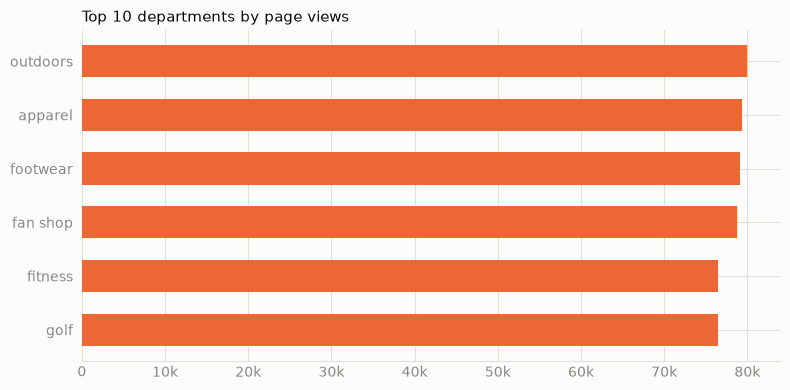

In [18]:
top_departments = logs['Department'].value_counts().head(10).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top_departments.index, top_departments.values, color=CATEGORICAL[1], height=0.6, zorder=3)
ax.set_title('Top 10 departments by page views', loc='left', color=INK, fontsize=11)
style_axis(ax, x_grid=True)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:,.0f}k' if v >= 1000 else f'{v:,.0f}'))
plt.tight_layout()
plt.show()

## Takeaways

- **Transactions file**: 180,519 order lines x 53 columns, fully populated except `Product Description` (100% null — dead column), `Order Zipcode` (~86% null), and single-digit nulls in `Customer Lname`/`Customer Zipcode`.
- **Date range**: orders span the full history recorded in the file (see §4) with a clear monthly volume trend — a good axis for time-series EDA.
- **Categoricals** (`Market`, `Order Region`, `Shipping Mode`, `Customer Segment`, `Order Status`, `Delivery Status`) are all low-cardinality and suitable for grouping/faceting.
- **Sales & profit** are concentrated in a handful of regions and categories — worth a Pareto-style follow-up.
- **Access logs** are a separate, larger clickstream file keyed by product/category/department rather than order ID — useful for browse-to-buy analysis but needs its own key-matching step before joining to the transactions file.

Suggested next notebooks: order-level profitability drivers, shipping/delivery-risk analysis, and a clickstream-to-purchase funnel.